# Máquinas Térmicas - Lección 11  
## Modelamiento de Turbinas de Gas

**Autor:** Camilo Bayona  
**Fecha:** 07/10/25

### Objetivos de aprendizaje

Al finalizar esta lección, el estudiante será capaz de:

- Explicar la **arquitectura y el acoplamiento de componentes** en un motor de turbina de gas (admisión, compresión axial/centrífuga, quemador, turbina y eje).  
- Formular **modelos 0D/1D** para cada componente y establecer **condiciones de compatibilidad** (masa, momento angular y energía).  
- Derivar y usar **relaciones de triángulos de velocidad** y la **ecuación de Euler para turbomáquinas** en compresores/turbinas.  
- Implementar un **modelo funcional** (estilo aire-estándar) para la **admisión** y la **compresión en cascada**.  
- Interpretar resultados intermedios $(\Pi, \dot{m}, M, \omega, \tau , \eta )$ y su impacto sobre **empuje y potencia**.


## 1. Introducción y arquitectura (caso PT6)

El empuje necesario que se requiere para que una aeronave genere sustentación es suministrado por un motor termico . En particular, los motores de turbina de gas tienen la capacidad de convertir la energía térmica en energía mecánica mediante la participación del flujo de aire que pasa a través de varios procesos de termofluidos atravez de sus componentes. La característica más importante de los motores de turbina de gas es que, a diferencia de los motores alternativos, se dedican secciones separadas del motor a los procesos de admisión, compresión, combustión, conversión de energía y escape. Esto también significa que todos los procesos se realizan simultáneamente y están fuertemente acoplados entre sí.

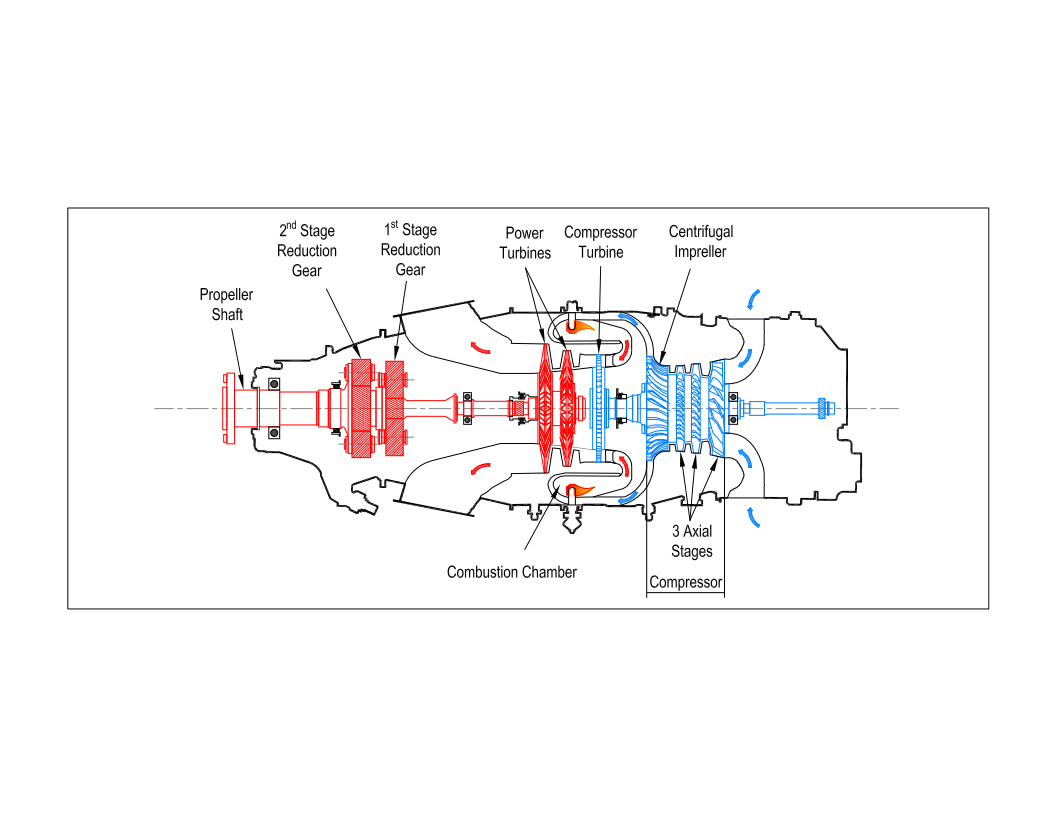*Figura 1* : Sección tranversal de un motor Pratt-Whitney PT6

## 2. Etapas de un motor turboprop



### 2.1 Admisión

El aire ingresa al motor a través de una pantalla de entrada de aire, que dirige el flujo de aire hacia el compresor axial de baja presión:
esta entrada de aire está diseñada para conducir adecuadamente la cantidad requerida de aire hacia la sección de compresión.
Dado que la toma de aire se encuentra en la parte trasera, y el requisito típico es proporcionar un flujo de aire laminar hacia el compresor, de modo que pueda operar con la máxima eficiencia, el conducto de entrada cambia suavemente desde oponerse a la dirección del flujo de aire hacia la dirección axial hacia adelante de la velocidad de la aeronave.

Por otro lado, la cantidad de aire que ingresa al motor puede medirse en esta sección. La medición de la cantidad de aire depende, entre otros factores, de la sección transversal de la entrada, de la velocidad de rotación del compresor, de las propiedades físicas (densidad) del aire circundante (entrada), pero también de la velocidad  de la aeronave.



### 2.2 Compresión

Uno de los factores más importantes que definen el rendimiento de un motor de turbina de gas es el sistema de compresión. El objetivo principal de la sección de compresión es suministrar aire en cantidad suficiente y en condiciones adecuadas para satisfacer los requisitos de combustión dentro de la cámara de combustión anular plegada.

En el motor de turbina de gas PT6 (utilizado para la aviación), la sección de compresión consta de tres etapas axiales y una sola etapa centrífuga, cada una considerada como un aumento en la presión del aire:
el aire fluye desde el conducto de entrada hasta el compresor de baja presión y luego a las dos siguientes etapas de flujo axial antes de pasar a la etapa centrífuga.

El cambio en las propiedades físicas del combustible afecta su pulverización a medida que pasa a través de los inyectores de combustible en la cámara de combustión. Esto tiene efectos en la temperatura máxima dentro de la cámara de combustión al iniciar el motor. En este sentido, el procedimiento de arranque debe diseñarse de manera rigurosa y debe establecerse para cada nuevo combustible de operación.




### 2.3 Quemador (Cámara de combustión)

El quemador es una configuración geométrica en la que el aire de entrada proveniente de la etapa de compresión es transportado hacia una llama donde su temperatura se eleva. El principal fenómeno que ocurre dentro de la llama es la convección y difusión de especies químicas (por ejemplo, hidrocarburos en el combustible y oxígeno en el aire), de tal manera que una reacción química oxidante entre esas especies, llamada combustión, libera calor en la corriente de aire. El calor liberado es necesario para que la reacción química sea activa, pero el calor restante se añade al aire, elevando su temperatura.



### 2.4 Turbina
Después de que la corriente de aire sale del quemador con la adición de calor de la combustión, pasa a través de una turbina de una sola etapa que impulsa los compresores a aproximadamente 45000 RPM. La combinación de las etapas del compresor y de la turbina en un solo eje se denomina "etapa del motor". Esta única turbina se llama "turbina del compresor".

El aire caliente fluye luego hacia las "turbinas de potencia", que están compuestas por dos etapas axiales que giran a alrededor de 30000 RPM y están conectadas al eje principal que impulsa la hélice. El aire se descarga cerca del escape y luego a la atmósfera, donde recupera sus condiciones originales de flujo libre.


## 3. Modelo matemático de la etapa de compresión

### 3.1 Admisión (modelo 0D con efectos de vuelo)

Una de las principales características de este motor de turbina de gas es que generalmente se monta hacia atrás en la góndola en la mayoría de las instalaciones de aeronaves. Esta característica hace que el flujo de aire se dirija hacia el interior de los componentes del motor en la misma dirección que el desplazamiento de la aeronave. Otra consecuencia es que la toma de aire se encuentra en la parte trasera del motor y, por lo tanto, el aire atraviesa el exterior de la aeronave (y el propio motor) antes de ingresar a la entrada de aire. El diseño del PT6A-65 se preocupa por guiar el aire de admisión hacia el motor mediante conductos que evitan enfrentarse a los gases de escape: dado que el requisito típico es proporcionar un flujo de aire laminar y limpio hacia el compresor, para que pueda funcionar con la máxima eficiencia, el conducto de entrada cambia suavemente desde oponerse a la dirección del flujo de aire hacia la dirección axial hacia adelante de la velocidad de la aeronave.

Definimos el componente de entrada como el acondicionador de aire de entrada: aunque nuestro modelo se limite a una operación en tierra, sin procesos de rarefacción del aire atmosférico que ingresa al motor, extendemos la posibilidad de operación del modelo durante condiciones de operación en vuelo. Este efecto se modela utilizando las relaciones para la presión y la temperatura del aire que se presentan en el diagrama de bloques de la Figura 3. En el modelo, patm y Tatm son la presión y la temperatura atmosférica, respectivamente. $M = υ/c$ es el número de Mach de vuelo que relaciona la velocidad de la aeronave υ con la velocidad del sonido $c = \sqrt{\gamma p_{atm}/\rho}$. El cociente entre los calores específicos del aire se denota como γ y η es la eficiencia politrópica. Utilizamos el subíndice 1 para etiquetar las variables termodinámicas del aire en la entrada. Ten en cuenta que cuando se supone que el motor opera en el banco de pruebas en tierra, el modelo iguala las condiciones de entrada a las condiciones atmosféricas p1 = patm y T1 = Tatm.




$$
p_{1}=p_{atm} \left[ 1 + \eta \ \frac{ \gamma - 1}{2} M^2 \right] ^ {\frac{\gamma}{\gamma-1}}  \ \ \ \ (1)
$$

$$
T_{1}=T_{atm} \left[ 1 + \frac{\gamma - 1}{2} M^2 \right].    \ \ \ \ \ \ \ \ \ (2)
$$



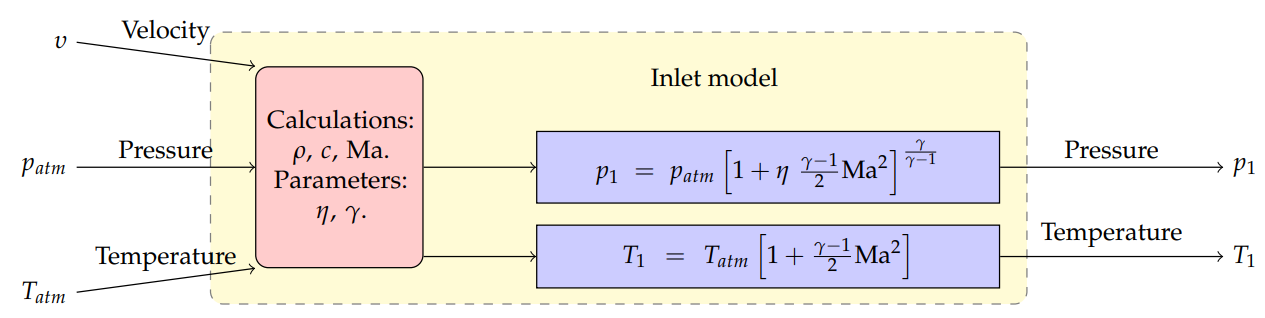

*Figura 2:* bloque de la admisión

### 3.2 Compresión: definición

La etapa de compresión se define desde el estado 1 en la entrada del compresor $(p_1, T_1)$ hasta el estado 2 en la salida del difusor $(p_2, T_2)$. Por lo tanto, abarca las tres etapas axiales, la etapa centrífuga y el difusor. Se requiere conocimiento de las condiciones de entrada (aguas arriba) del aire, como la temperatura y la presión, así como la velocidad de rotación del eje giratorio del motor. Además, es obligatorio conocer la geometría del compresor en cada etapa para aplicar los balances de continuidad, momento y energía en los que dependen la caída de entalpía (y, por lo tanto, la relación de presión y eficiencia) y el flujo de masa.

Dado que cada sección de compresión está compuesta por etapas sucesivas de palas rotativas (rotores) y álabes guía estacionarios (estatores), analizamos en cada etapa rotor-estator la transmisión de la energía mecánica del eje al flujo de aire y componemos el rendimiento completo del compresor agregando las múltiples etapas de compresión sucesivas.

Modelamos los fenómenos termo-fluidos en las etapas de compresión a partir del análisis de la aerodinámica del flujo sobre los elementos individuales de las palas del compresor. A continuación, se describe cada una de las etapas axiales y centrífugas del proceso de compresión, donde un modelo simplificado del flujo de aire que cruza las palas reproduce las características más importantes del flujo de masa, la relación de presión y la potencia requerida.




### 3.3 Compresión axial (una etapa genérica $i$)
Primero, comenzamos con las etapas axiales del compresor. Para simplificar, asumimos que las palas axiales son delgadas en lugar de tener la geometría completa de una sección transversal de perfil alar.

Analizamos el caso de una sola etapa $i$ del compresor axial, donde un rotor precede a un estator. Para cada etapa del compresor axial consideramos el mismo radio de cubo $r^i$ para el rotor que para el estator. También hacemos esta suposición para el radio del eje $r_0^i$ en cada etapa axial. Por lo tanto, el área transversal del flujo $A^i=\pi[(r^i)^2-(r_0^i)^2]$ permanece constante.

Sin embargo, consideramos diferentes áreas transversales entre etapas consecutivas, de modo que la componente axial de la velocidad se puede calcular para conservar la masa: en el caso del compresor axial de flujo múltiple, las palas de cada etapa sucesiva del compresor se vuelven más pequeñas a medida que el aire se comprime aún más. En cada etapa rotor-estator consideramos la sección transversal de solo una pala de estator y una pala de rotor a medida que se mueve verticalmente, sabiendo que la siguiente pala de rotor pasa poco después. Esta es la conocida aproximación bidimensional de turbomáquinas en cascada.

La figura 2 muestra el flujo a través de una etapa típica del compresor axial. Las estaciones son: el espacio justo antes del rotor de la etapa del compresor, el espacio entre el rotor y el estator, y el espacio justo después del estator (que coincide con el espacio justo antes del siguiente rotor). Suponemos que el flujo incide en la pala de manera paralela al borde de ataque de la pala y que el flujo también sale de la pala de manera paralela al borde de fuga de la pala. La suposición anterior es precisa cuando el compresor opera cerca de las condiciones de diseño .  Definimos la inclinación de la pala utilizando dos ángulos diferentes. El primer ángulo es el ángulo de borde de ataque $\beta^i_l$ (o ángulo de paso) y el segundo es el ángulo de borde de fuga $\beta^i_t$. Estos ángulos de las palas definen los ángulos del flujo en coordenadas móviles (sistema de referencia relativo).


El flujo pasa a través de las palas del rotor en movimiento y sale del borde de fuga hacia arriba debido a la geometría de la pala: las variaciones radiales en el flujo a lo largo de los elementos de las palas del compresor se consideran despreciables en comparación con el cambio tangencial.

El concepto de triángulos de velocidad se basa en el análisis de velocidad relativa realizado en la cinemática de partículas.

Los vectores de velocidad del fluido que se mueve en el borde de ataque y en el borde de fuga de la pala se componen utilizando las velocidades de rotación instantáneas de la pala y la velocidad relativa del flujo que incide en la dirección de la pala. La velocidad relativa es aquella que se observa desde el marco de referencia relativo de un observador que se mueve con la pala en rotación.

Cada una de estas velocidades, con los subíndices $l$ y $t$ que denotan las posiciones de entrada y salida de la pala del rotor, se calcula para la $i$-ésima etapa rotor-estator utilizando las siguientes relaciones vectoriales:


Aquí, las velocidades $(\boldsymbol{v})^i, (\boldsymbol{v})^i_{\text{rel/pala}}$ y $(\boldsymbol{v})^i_{\text{pala}}$ se refieren respectivamente a la velocidad absoluta del fluido, la velocidad relativa del fluido que pasa paralela a la pala y la velocidad absoluta de la pala mientras rota. La velocidad absoluta de la pala $(\boldsymbol{v})^i_{\text{pala}}$ está relacionada con la velocidad angular del rotor $\omega$, de modo que la velocidad de la pala del rotor en el radio tiene una magnitud de $\omega r^i$ en dirección vertical.


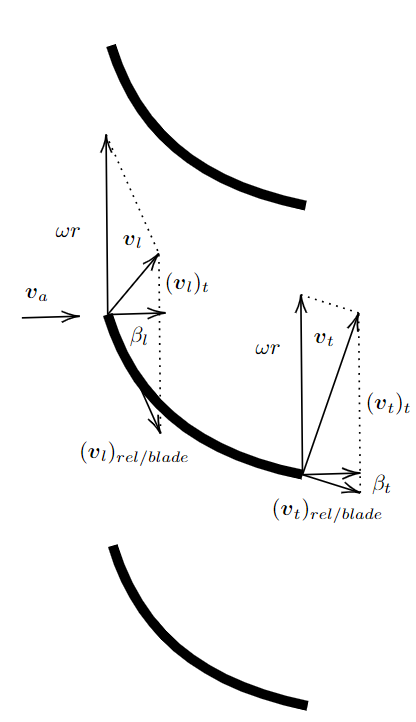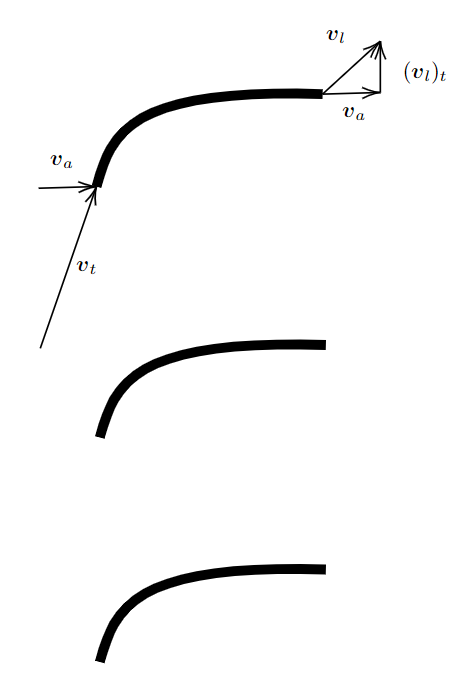

*Figura 3 :* geometria del flujo de la etapa de compresión axial


El flujo ingresa a una velocidad $\boldsymbol{v}^i_a$ considerada en dirección axial. Dado que el área transversal circunferencial está definida por los radios del eje y el cubo, el flujo volumetrico es $\dot{V}=\pi[(r^i)^2-(r_0^i)^2]v_a$.

La magnitud de la velocidad en la dirección axial se puede calcular en términos del flujo volumétrico y el área transversal de la etapa como $v^i_a=\dot{V}/\pi[(r^i)^2-r_0^2]$. Dado que la componente axial de la velocidad debe permanecer constante a lo largo del flujo a lo largo de la pala para conservar la masa, la magnitud de la velocidad relativa del fluido que fluye paralelo a la pala $(\boldsymbol{v})^i_{\text{rel/pala}}$ se puede calcular utilizando relaciones trigonométricas. De hecho, la componente axial de la velocidad resultante $(\boldsymbol{v})^i_a$ debe coincidir siempre con la velocidad axial del flujo. En el caso de la componente tangencial de la velocidad del flujo $(\boldsymbol{v})^i_t$, se puede calcular utilizando la relación trigonométrica del ángulo de inclinación $\beta^i$ y el triángulo de velocidad de la siguiente manera:

$$
(v_l)^i_t= \omega r^i - v^i_a\tan \beta^i_l \ \ \ \ (3)
$$
$$
(v_t)^i_t= \omega r^i - v^i_a\tan \beta^i_t \ \ \ \ (4)
$$

El efecto del estator en el flujo garantiza una salida axial, suponemos entonces que no hay ninguna vorticidad en el flujo. En el caso de una sección transversal de área constante, las velocidades del flujo en la salida del estator coinciden con la velocidad de entrada en el rotor de la siguiente etapa. En el caso actual, hay una variación en la velocidad axial $v_a$ a través de las etapas debido al cambio en la sección transversal.

Para evaluar el par en el eje rotativo, utilizamos el equilibrio del momento angular sobre el volumen de control que representa la sección del compresor axial. Elegimos un volumen de control que rodea las palas figura 3, desde el radio $r_0^i$ hasta el radio $r^i$. Este análisis ignora el flujo de fluido dentro del volumen de control, especialmente los detalles de las palas individuales.



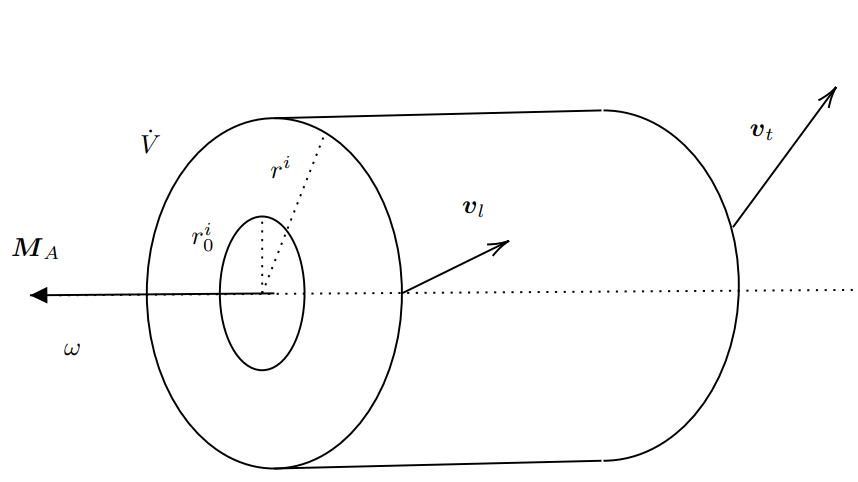

*Figura 4 :*  Volumen de control de la etapa de compresión axial.


En cambio, suponemos velocidades uniformes a lo largo de las áreas transversales del volumen de control: el área transversal de entrada de la punta del borde de ataque de la pala y el área transversal de salida de la pala. Esta suposición significa que tenemos un número infinito de palas infinitamente delgadas.

Aquí aplicamos la ecuación de turbomáquinas de Euler, que se deriva del equilibrio del momento angular en la porción del compresor axial.



$$
\boldsymbol{M}_A=\sum_\text{out}\boldsymbol{r}\times\dot{m}_a\boldsymbol{v}-\sum_\text{in}\boldsymbol{r}\times\dot{m}_a\boldsymbol{v} \ \ \ \ (5)
$$
donde $\dot{m}_a$ se refiere a la tasa de flujo de masa de aire que entra en el compresor (y en el motor), y que puede calcularse en función de la tasa de flujo volumétrico $\dot{V}$.
La ecuación de equilibrio del momento angular establece que el momento total en el eje es igual al cambio entre el momento angular del flujo que cruza las superficies del volumen de control.
Dado que la componente tangencial de la velocidad del flujo es la única componente relevante en el producto cruzado en el compresor de flujo axial, cada etapa $i$ tiene un balance neto de momento angular en la dirección del eje esta dado por:

$$
(M_A)^i=r\dot{m}_a[(v_t)^i_t-(v_l)^i_t] \ \ \ \ (6)
$$

La relación anterior se puede escribir en función de la tasa de flujo volumétrico y las componentes tangenciales de la velocidad del flujo, de modo que se llega a

$$
(M_A)^i=r(v_a^i)^2\rho\pi[(r^i)^2-r_0^2][\tan\beta^i_l-\tan \beta^i_t] \ \ \ \ (7)
$$

En nuestro modelo, no hay pérdidas irreversibles en las etapas de compresión, por lo tanto, se considera una eficiencia total.
Esto implica que la potencia del eje es la misma que la potencia entregada al aire, y que la relación entre la potencia del eje y la velocidad del flujo se da por
$$
(\dot{W}_A)^i=\omega r(v_a^i)^2\rho\pi[(r^i)^2-r_0^2][\tan\beta^i_l-\tan \beta^i_t]. \ \ \ \ (8)
$$

La cabeza de presión neta $H_A^i$ inducida en la $i-$ésima etapa del compresor axial se puede calcular como $\omega(M_\text{shaft})^i=\rho g \dot{V}H_A^i$, donde $g$ es la aceleración debida a la gravedad.
Por lo tanto, la cabeza de presión neta se calcula como

$$
H_A^i=\frac{1}{g}\omega rv_a^i\left(\tan\beta^i_l-\tan \beta^i_t\right). \ \ \ \ (9)
$$

La relación de compresión $\Pi$ se define como la presión absoluta de salida dividida por la presión absoluta de entrada.
Calculamos esta relación para cada etapa del compresor axial multietapa como $\Pi^i= (p^i+H_A^i)/p^i$, donde $p^i+H_A^i$ es la presión de descarga en la $i-$ésima etapa y $p^i$ es la presión de entrada de la etapa.

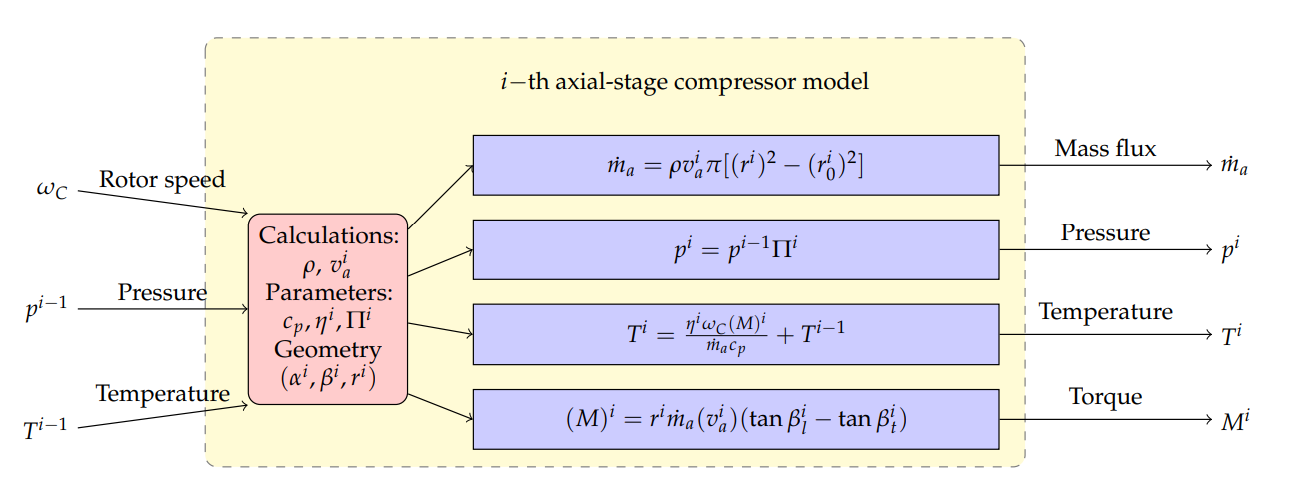

*Figura 5 :* Bloque de compresión axial

### 3.4 Compresión centrífuga (una etapa)

En el caso de la etapa de compresión centrífuga, se realiza un análisis similar. Primero, las palas también están construidas de lámina de metal y la suposición de palas delgadas se ajusta bien en el modelo fluido. En la Figura~\ref{fig:CentrifugalCutView} se muestran las definiciones geométricas de la etapa de compresión centrífuga. Consideramos dos radios diferentes en la definición del compresor: el radio de entrada $r_1$ y el radio de salida $r_2$. El área de sección transversal circunferencial $A_1$ se puede definir mediante el radio y el ancho de la pala $b_1$ en la parte de entrada del compresor, de modo que $A_1=2\pi r_1 b_1$. Del mismo modo, el área de sección transversal circunferencial en la salida también se define utilizando el ancho $b_2$ de la pala y el radio como $A_2=2\pi r_2 b_2$. Para completar, se utilizan las componentes de velocidad normales del flujo en la entrada y salida de la pala $(\boldsymbol{v}_1)_n$ y $(\boldsymbol{v}_2)_n$, respectivamente, y las componentes de velocidad tangencial del flujo en la entrada y salida $(\boldsymbol{v}_1)_t$ y $(\boldsymbol{v}_2)_t$ se utilizan en la descripción del equilibrio.

La tasa de flujo volumétrico a través del compresor centrífugo es $\dot{V}=2\pi r_1b_1(v_1)_n=2\pi r_2b_2(v_2)_n$, que es igual a la tasa de flujo que pasa por las etapas axiales anteriores. Suponemos que el flujo de entrada es completamente en la dirección normal $(v_1)_n$, y por lo tanto, la velocidad normal en la salida de la pala se puede calcular con la conservación de la masa como $(v_2)_n=\left(r_1b_1/r_2b_2\right)(v_1)_n$. El cálculo de la velocidad normal de salida se puede ver como una dependencia geométrica solamente.

La Figura 4 muestra el flujo a través de la etapa de compresión centrífuga. Suponemos que la velocidad de rotación del compresor centrífugo coincide con el compresor de flujo axial en la Figura 3. De manera similar al compresor axial, suponemos que el flujo incide en la pala paralelamente a la parte de entrada de la pala y que el flujo también sale de la pala paralelamente al borde de salida de la pala. Usamos el sistema de referencia rotativo para evaluar la velocidad del flujo en las partes de entrada y salida de la pala. También definimos los ángulos de inclinación de la pala medidos desde la dirección tangencial en las partes de entrada y salida de la pala, $\beta_1$ y $\beta_2$, respectivamente. Las relaciones vectoriales para las partes de entrada y salida de la pala son, respectivamente,
$$\boldsymbol{v}_1=(\boldsymbol{v}_1)_{\text{blade}}+(\boldsymbol{v}_1)_{\text{rel/blade}},$$
$$\boldsymbol{v}_2=(\boldsymbol{v}_2)_{\text{blade}}+(\boldsymbol{v}_2)_{\text{rel/blade}}.$$
La velocidad absoluta de la pala $(\boldsymbol{v}1){_{blade}}$ y $(\boldsymbol{v}2){_{blade}}$ está relacionada con la velocidad angular del rotor $\omega$, de modo que la velocidad de la pala del rotor en los radios de entrada y salida tiene respectivamente una magnitud de $\omega r_1$ y $\omega r_2$ en dirección tangencial.



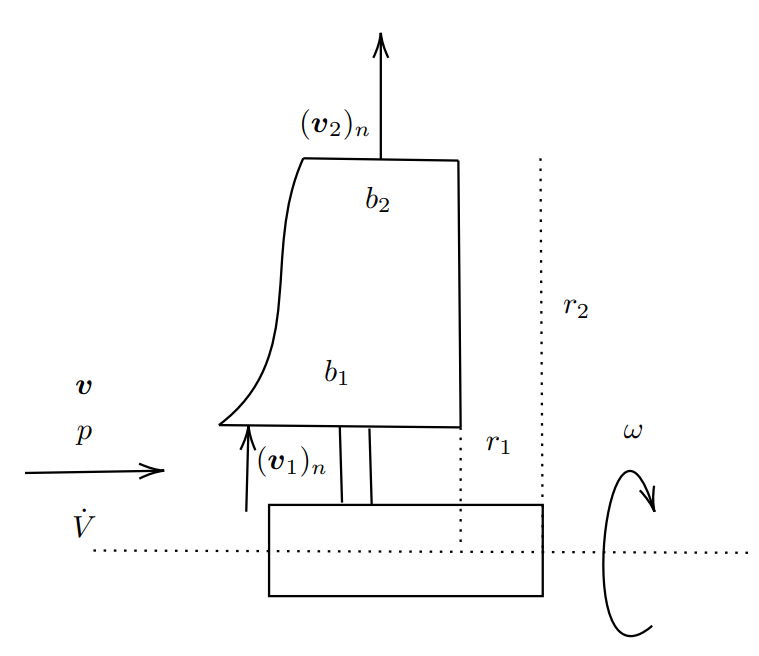

*Figura 6 :* Geometria de la etapa de compresión centrifuga

En este punto, construimos el triángulo de velocidades, que se muestra en la Figura 5, y utilizamos el hecho de que la componente normal de la velocidad del flujo ya se conoce a partir de la conservación de la masa. El análisis trigonométrico del triángulo de velocidades también tiene en cuenta los ángulos de inclinación de la pala medidos desde la dirección tangencial. La suma de los vectores de velocidad en dirección tangencial da.

$$
(v_1)_t= \omega r_1 - (v_1)_n/\tan \beta_1 \ \ \ \ (10)
$$

$$
(v_2)_t= \omega r_2 - (v_2)_n/\tan \beta_2.  \ \ \ \ (11)
$$

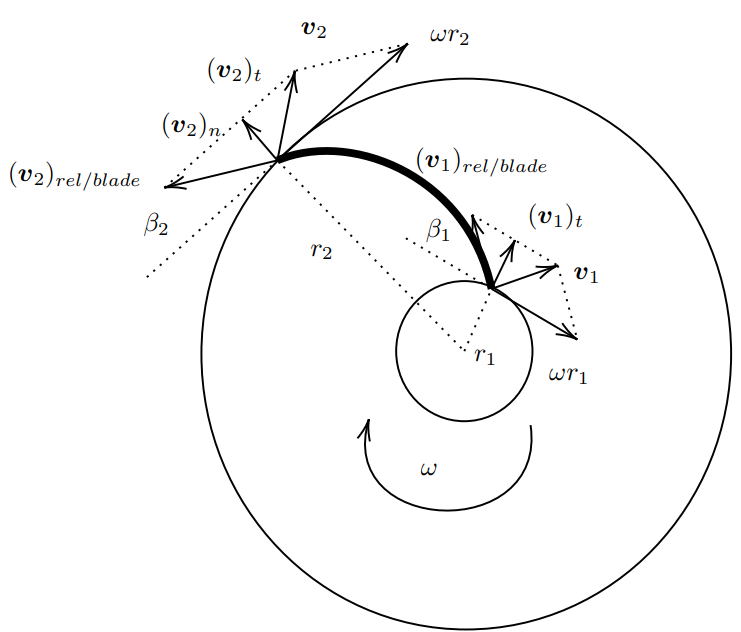

*Figura 7:* Vista axial de la etapa de compresión centrifuga

Para evaluar el par en el eje giratorio, utilizamos el balance de momento angular  sobre un cierto volumen de control que representa la sección del compresor centrífugo. Este volumen de control está representado en el diagrama de la Figura 5. Elegimos el volumen de control para rodear un número infinito de palas, desde el radio $r_1$ hasta el radio $r_2$. En el caso del compresor de flujo centrífugo, tiene un equilibrio neto de momento angular de

$$
M_C=r_2\dot{m}_a(v_2)_t-r_1\dot{m}_a(v_1)_t \ \ \ \ (12)
$$

En la dirección del eje giratorio. Observa cómo en esta etapa centrífuga, la componente tangencial de las velocidades del flujo también es la única componente relevante en el producto cruz de (5).

También reemplazamos la tasa de flujo másica $\dot{m}_a$ en (12), de modo que ahora se escribe en términos de la tasa de flujo volumétrico $\dot{V}$, y utilizamos la definición de las componentes tangenciales de las velocidades en las partes de entrada y salida dada por (10) y (11). Esto lleva a la siguiente expresión para el cálculo del par neto en el eje giratorio:

$$
M_C=\rho\dot{V}\left[r_2\left(\omega r_2 - (v_2)_n/\tan \beta_2\right)-r_1\left(\omega r_1 - (v_1)_n/\tan \beta_1\right)\right].
$$

Como se comentó antes, no hay pérdidas irreversibles en las etapas de compresión, y por lo tanto, también se considera que la eficiencia del compresor centrífugo transforma completamente la energía mecánica del eje en energía cinética del aire. Por lo tanto, la potencia del eje entregada al aire se puede calcular como
\begin{align}
\dot{W}_C=\omega\rho\dot{V}\left[r_2\left(\omega r_2 - (v_2)_n/\tan \beta_2\right)-r_1\left(\omega r_1 - (v_1)_n/\tan \beta_1\right)\right].\ \ \ \ (13)
\end{align}
La expresión anterior se puede igualar con la expresión termodinámica para el incremento de la energía del aire. En realidad, los procesos de compresión no son isotrópicos. Es un proceso politrópico (real) con aumento de la entropía debido a la fricción y las pérdidas en el compresor y la línea de proceso termodinámico se inclina hacia la derecha debido a este aumento de la entropía del flujo. Sin embargo, la pérdida neta de presión inducida por el compresor se puede calcular como un proceso isotrópico con la siguiente expresión:
\begin{align}
H_C=\frac{1}{g}\left[\omega r_2\left(\omega r_2 - (v_2)_n/\tan \beta_2\right)-\omega r_1\left(\omega r_1 - (v_1)_n/\tan \beta_1\right)\right]. \ \ \ \ (14)
\end{align}

La relación de presión $\Pi$ se calcula de manera idéntica a la del compresor de flujo axial, con la presión absoluta de salida dividida por la presión absoluta de entrada $\Pi_C= (p_1+H_C)/p_1$, donde $p_1+H_C$ es la presión de descarga del compresor centrífugo, y $p_1$ es la presión de entrada del compresor centrífugo.

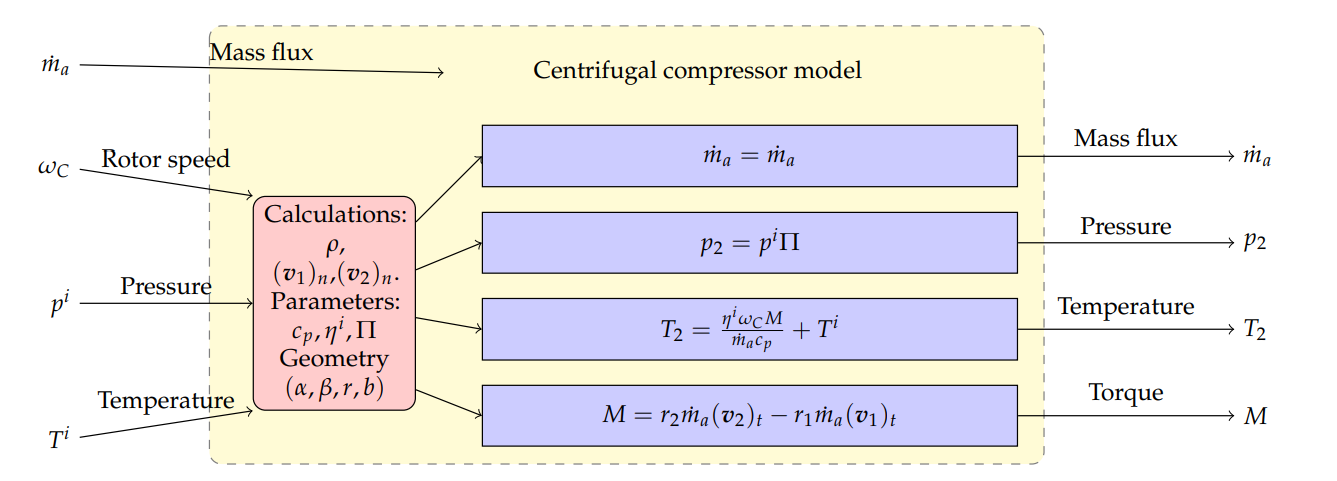

*Figura 8 :* Bloque de compresión centrifuga

## 4. Quemador (modelo 0D con balance transitorio)

El proceso de combustión se define desde el estado 2 en la salida del compresor $(p_2, T_2)$ hasta el estado 3 en la entrada de la turbina $(p_3, T_3)$.

Las descripciones convencionales requieren modelos matemáticos complejos que relacionan la aerodinámica, la termodinámica y la química de la combustión dentro de la cámara . Estos modelos resuelven la cinética de la reacción de combustión junto con las ecuaciones de balance de masa, momentum y energía dentro del quemador, lo que resulta en modelos inestables detallados pero costosos. Por esta razón, aplicamos un modelo de combustión no estacionario 0-dimensional que tiene como objetivo modelar el aumento de energía del aire y la caída de presión a través de la cámara de combustión, pero que es simple de acoplar con los demás componentes que representan la respuesta dinámica del motor. Aplicamos el balance de masa y energía en el quemador de la turbina de gas y tenemos en cuenta las propiedades del combustible.

Por un lado, el balance de masa dentro del quemador iguala la cantidad de flujo de aire entrante $\dot{m}_{a}$ y el flujo de combustible $\dot{m}_{f}$ a los gases de combustión en la salida $\dot{m}_g$. La cámara de combustión funciona como un acumulador de masa, donde el cambio temporal del flujo de aire en la entrada está relacionado con la salida y el volumen de la cámara $V_B$ por la siguiente ecuación:

$$
V_B\frac{d\rho}{dt} = \dot{m}{a}+\dot{m}{f} - \dot{m}_{g} \ \ \ \ \ \ \ (15)
$$

Podemos introducir la ley de los gases ideales para modelar el aire dentro del quemador $p=\rho R T$, de modo que la derivada total de la presión respecto al tiempo se da por $\frac{dp}{dt} = \frac{d\rho}{dt} (RT) + \frac{dT}{dt} (\rho R) $. Si introducimos esta derivada en (15), resulta en:

$$
\frac{dp_3}{dt} = \frac{RT_{3}}{V_B} \left(\dot{m}{a} - \dot{m}{g} + \dot{m}_{f}\right) + \rho R \left( \frac{dT_3}{dt} \right)\ \ \ \ \ \ \ \ \  (16)
$$

Por otro lado, el proceso de combustión en el quemador ocurre con una disminución de la presión, pero resulta en un aumento de la temperatura del aire.

La potencia neta del motor de turbina de gas está relacionada con la cantidad de combustible que se quema en el quemador: la cantidad de energía química transferida al aire (que luego se transforma en energía mecánica en la turbina) depende del tipo de combustible utilizado.

El calor agregado al flujo de aire se calcula a partir del balance de energía dentro de la cámara de combustión:

$$
\dot{m}_a h_2 +\dot{m}_f \text{LHV}_f=\left(\dot{m}_a+\dot{m}_f\right)h_3 \ \ \  \ \ \ (17)
$$

donde $LHV$ es el Valor de Calor Inferior del combustible, que es la energía entregada en el proceso de combustión (teniendo en cuenta la evaporación del vapor en el combustible líquido), $h_2$ es la entalpía del aire en la entrada del quemador y $h_3$ es la entalpía de los gases quemados, que puede aproximarse mediante el calor específico del aire.

Dadas todas las suposiciones anteriores, el balance de energía resulta en:

$$
\dot{m}_a c_{p,air}T_2 +\dot{m}_f \text{LHV}_f=\left(\dot{m}_a+\dot{m}_f\right)c_{p,air}T_3 \ \ \  \ \ \ (18)
$$

Dado que no estamos considerando la cinética de la reacción, el combustible está completamente caracterizado por su flujo de masa y también por su Valor de Calor Inferior (LHV, por sus siglas en inglés).

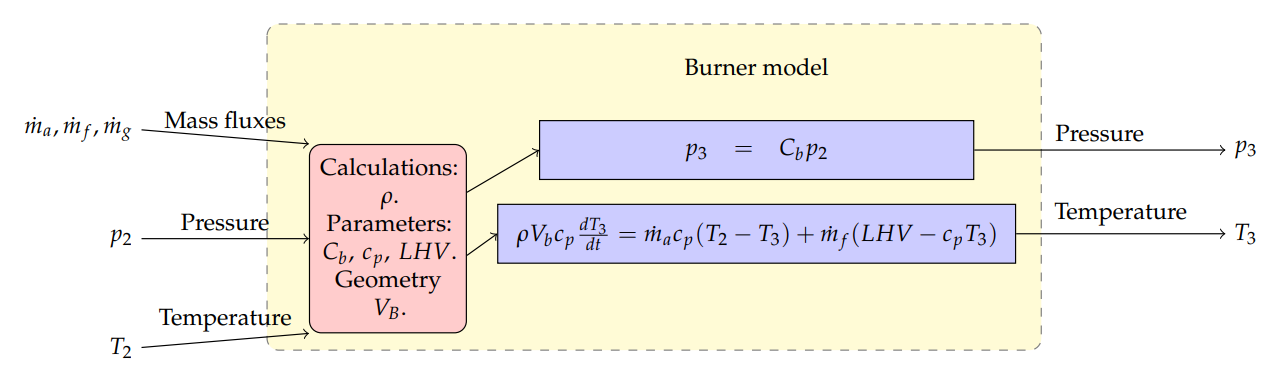

*Figura 9 :* Bloque del quemador

## 5. Turbina (una etapa axial $j$)

El proceso de la turbina se define desde el estado 3 en la salida de la cámara de combustión $(p_3, T_3)$ hasta el estado 4 en la salida del motor $(p_4, T_4)$.

De manera similar al análisis del compresor de flujo axial, se puede derivar un modelo preciso del rendimiento de la turbina a partir de un cálculo detallado de la aerodinámica del flujo sobre los elementos de las palas individuales. Dado que el análisis es prácticamente idéntico al de las  etapas de compresión , en esta parte presentamos solo las relaciones que se obtienen para una sola etapa $j-$ de la turbina de flujo axial.

De hecho, el triángulo de velocidades mostrado en la Figura 6 resulta en una componente axial de la velocidad del flujo resultante $(\boldsymbol{v})^j_a$ que siempre debe coincidir con la velocidad axial del flujo, y una componente tangencial de la velocidad del flujo $(\boldsymbol{v})^j_t$, que se puede calcular utilizando la relación trigonométrica del ángulo de inclinación $\beta^j$, de la siguiente manera:

$$
(v_l)^j_t= \omega r^j - v^j_a \tan \beta^j_l \ \ \ \ \ (19)
$$

$$
(v_t)^j_t= \omega r^j - v^j_a \tan \beta^j_t \ \ \ \ \ (20)
$$

La ecuación del modelo (6), que también funciona para la etapa de la turbina, se expresa en términos del caudal volumétrico y de las componentes tangenciales de la velocidad del flujo (19) y (20), de manera que :

\begin{align}
(M_T)^j=r(v_a^j)^2\rho\pi\left((r^j)^2-r_0^2\right)\left(\tan\beta^j_l-\tan \beta^j_t\right). \ \ \ \ \ (21)
\end{align}

En el caso de la turbina, la diferencia $\left(\tan\beta^j_l-\tan \beta^j_t\right)$ conduce a un resultado negativo del par motor, ya que el ángulo de salida $\beta_t$ es mayor que el ángulo de entrada $\beta_l$. Esto indica que el par en el eje gira en la dirección opuesta al ejercido en la etapa de compresión.

La potencia entregada al eje giratorio (en cada etapa axial de la turbina) es igual a:

\begin{align}
(\dot{W}_T)^j=\omega r(v_a^j)^2\rho\pi\left((r^j)^2-r_0^2\right)\left(\tan\beta^j_l-\tan \beta^j_t\right), \ \ \ \ (22)
\end{align}

y la cabeza de presión neta $H_T$ convertida por la turbina se puede calcular como:

\begin{align}
H^j_T=\frac{1}{g}\omega rv_a^j\left(\tan\beta^j_l-\tan \beta^j_t\right) \ \ \ \ \ (23)
\end{align}

En el caso de la turbina de flujo axial multietapa, el área de los elementos de las palas suele aumentar aguas abajo entre las etapas, ya que la presión se pierde en etapas sucesivas. Esto significa que el radio $r^j$ de cada etapa $j-$ésima puede variar, al igual que la velocidad axial $v_a^j$, ya que la masa debe conservarse.



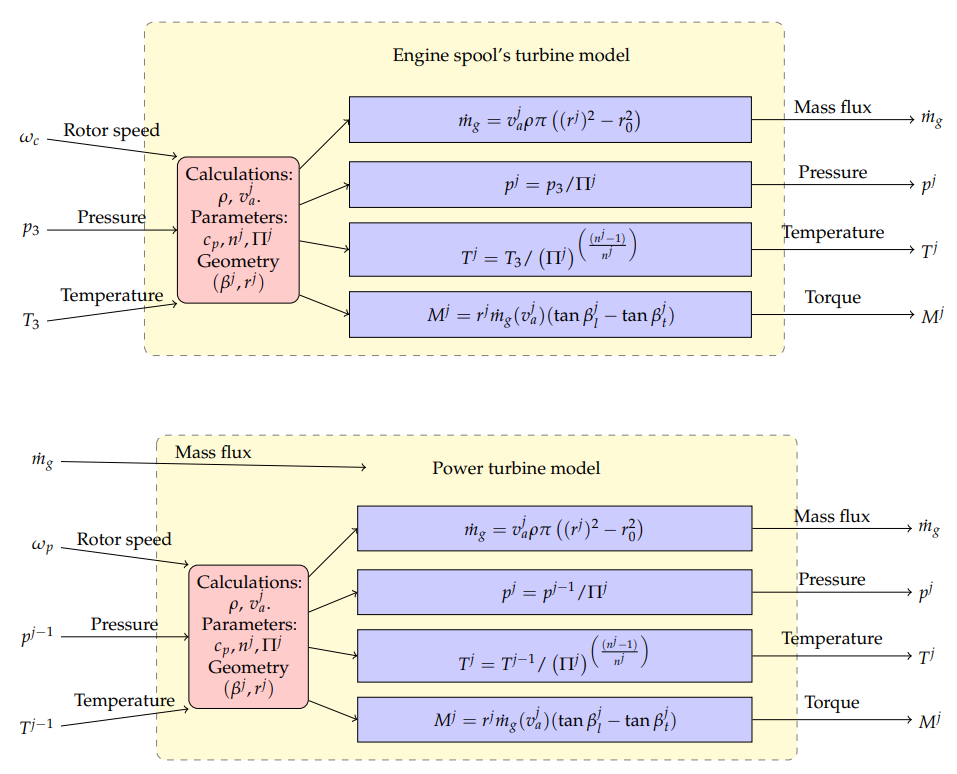

*Figura 10 :* Bloques de la turbina

## 6. Eje rotativo y compatibilidades

Se puede ver fácilmente que la potencia de aceleración del eje debe igualar el equilibrio entre la potencia de la turbina, la potencia de compresión y la potencia de carga (o parasítica).
El eje rotativo se modela aplicando el equilibrio del momento angular en todo el eje rotativo. Esto ya se ha hecho (parcialmente) cuando se aplicó el equilibrio del momento angular a las etapas de compresión y turbina.
Utilizamos la suposición de cuerpo rígido y aplicamos la ecuación rotacional $ I_R (d \boldsymbol{\omega}/dt) = \sum \boldsymbol{M}$ para equilibrar los torques aplicados al eje, en lo que se refiere como una \textit{condición de compatibilidad} del motor.
Por lo tanto, el equilibrio del momento angular del eje rotativo se calcula como

\begin{align}
I_R \frac{d \omega}{dt} = \sum_{j=1}^{3} \left(M_T\right)^j - \sum_{i=1}^{3} \left(M_A\right)^i - M_C -M_L \ \ \ \ \ \ (27)
\end{align}

donde $I_R$ es el momento de inercia de masa del eje rotativo alrededor de su eje de rotación, $M_L$ es el torque de carga y $\omega=N\pi/60$ es la velocidad angular del eje que se puede calcular en función de sus $N$ Revoluciones Por Minuto (RPM).

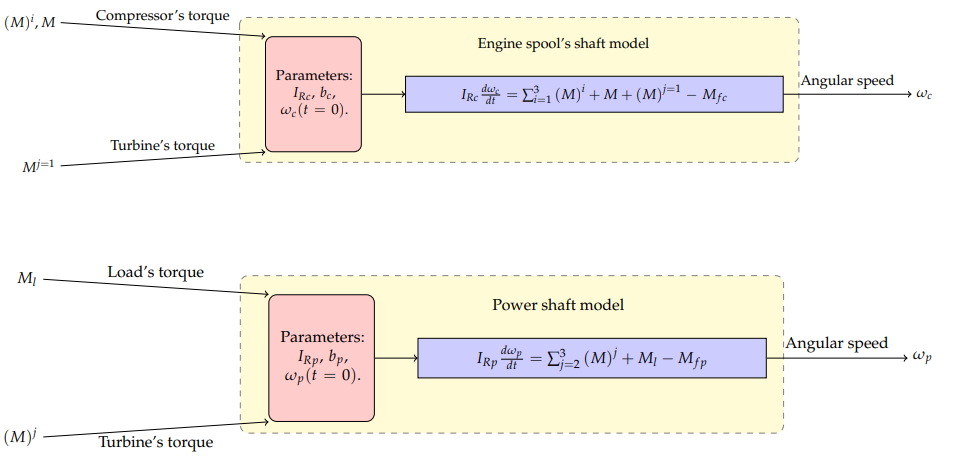

*Figura 11 :* Bloque de eje de potencia

#### Ecuaciones de compatibilidad

La descripción física de cada componente del motor debe cerrarse acoplando los diferentes componentes a lo que se refiere como las condiciones de compatibilidad. Las condiciones de compatibilidad generales se hacen evidentes a partir del diagrama de bloques del sistema del motor que se muestra en la Figura.

Las condiciones de compatibilidad de masa están relacionadas con la conservación del caudal de masa de aire. El caudal de masa de aire $\dot{m}_a$ en la entrada se calcula conociendo el ángulo del aire en la primera etapa axial, de modo que la velocidad axial se puede calcular sabiendo la velocidad de rotación y los parámetros geométricos de las palas del rotor. Se ha explicado que $\dot{m}_a$ se conserva entre las etapas de la sección de compresión. Sin embargo, la condición de compatibilidad de masa difiere sustancialmente cuando el aire ingresa al quemador: el caudal de masa de los gases de escape $\dot{m}_g$ no solo está relacionado con el flujo de aire comprimido $\dot{m}_a$ que reacciona con el flujo de masa del combustible $\dot{m}_f$, sino que también depende del flujo a través de la sección de turbina y del escape del motor. Aquí, la condición de compatibilidad está relacionada con el caudal de masa resultante de cada etapa de la turbina. Se proporcionará una explicación más detallada sobre esta condición de compatibilidad en la próxima sección.

Por otro lado, la condición de compatibilidad del momento angular es el equilibrio de los torques aplicados a cada eje giratorio. Es fácil entender que la velocidad de rotación de las etapas de compresión axial y centrífuga coincide con la del turbocompresor a través del eje del motor. En la misma línea, la velocidad del eje de las turbinas de potencia coincide con la velocidad del eje de la hélice a través de la caja de cambios de reducción.

Finalmente, las condiciones de compatibilidad energética están asociadas con las variables termodinámicas del aire en cada una de las etapas del motor. Se ha mencionado que el aire ingresa a cada etapa consecutiva con las condiciones de presión y temperatura que adquiere en la etapa inmediatamente anterior.

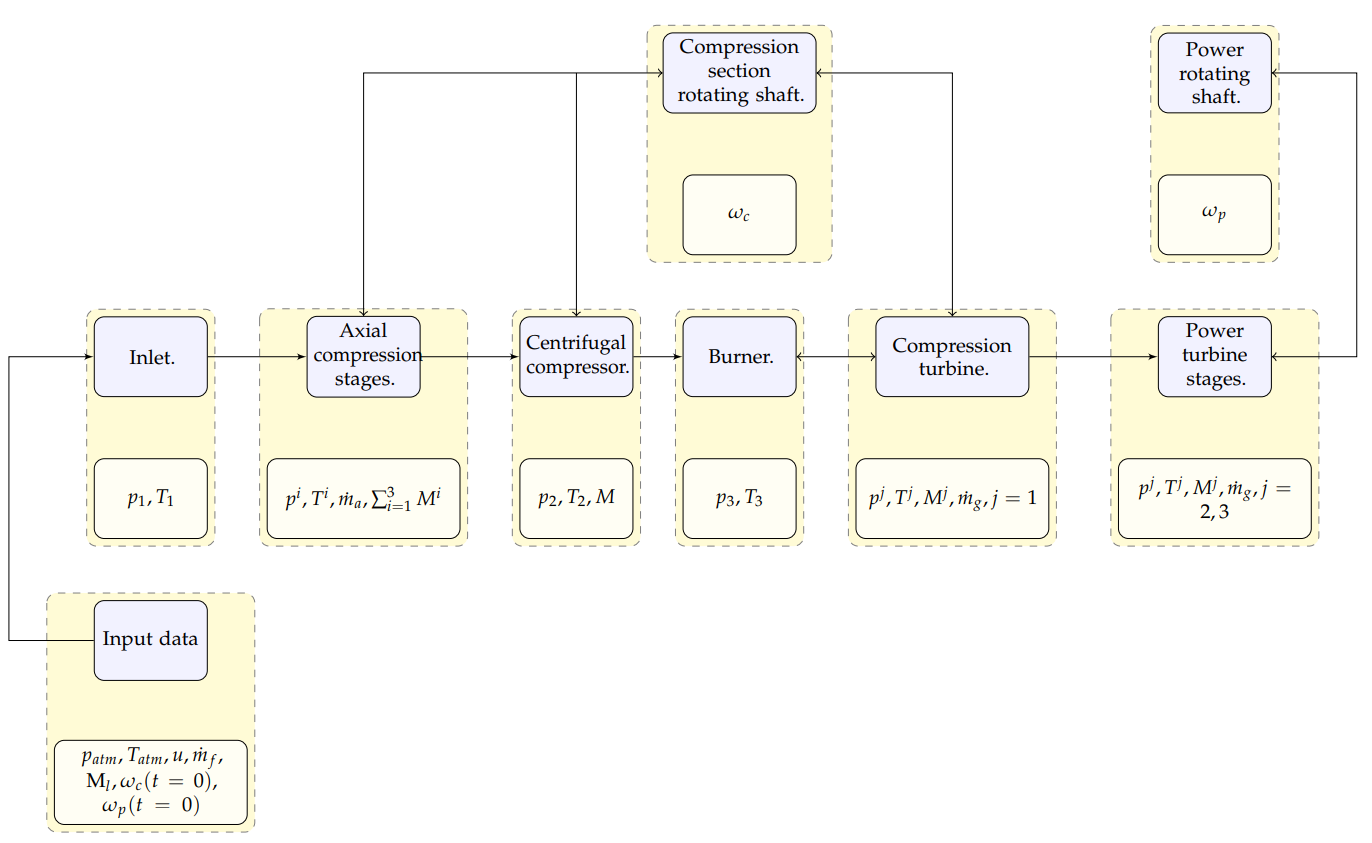

Diagrama de bloques del modelo de un motor  PT6A-65



## 7. Ejemplo de simulación

El modelo incluye todas las etapas fundamentales del ciclo: admisión, compresión axial y centrífuga, combustión y expansión en la turbina. A partir del flujo de gas disponible y de las características geométricas y operativas del sistema, se determinan los incrementos de presión y temperatura en cada etapa, así como las potencias asociadas.

El proceso inicia con el aire ambiente que ingresa al sistema. Aunque el modelo considera velocidad de vuelo cero, se calcula igualmente la presión y temperatura de entrada tras el proceso de admisión idealizado. Con el flujo másico de aire determinado a partir de la relación aire–combustible requerida, el cálculo procede a la etapa de compresión. Para ello, se modelan tres etapas axiales en serie, donde cada una utiliza la geometría del álabe (radios, ángulos de ataque y salida) y la velocidad angular del rotor para determinar el cambio de momento angular, el trabajo aportado y la elevación de presión y temperatura correspondiente mediante la ecuación de Euler para turbomáquinas.

Posteriormente, el flujo pasa a una etapa centrífuga adicional, donde la presión y la temperatura vuelven a incrementarse debido a la acción dinámica del impulsor. En esta etapa también se utilizan los radios del impulsor, el caudal volumétrico, los ángulos de las paletas y la velocidad angular para determinar el trabajo y el aumento de presión.

Una vez completada la compresión, el aire comprimido entra a la cámara de combustión, donde se mezcla con el flash gas calculado previamente. Usando el poder calorífico del gas y la eficiencia de combustión, se determina el incremento total de energía del flujo y se obtiene la temperatura de salida del quemador. Esta temperatura es fundamental porque define las condiciones de entrada a la turbina.

La turbina se modela como una etapa que extrae trabajo del flujo caliente. Aplicando nuevamente la ecuación de Euler y la geometría de la etapa, se calcula el torque, la potencia mecánica entregada y la caída de temperatura resultante del proceso de expansión. La potencia neta del ciclo se obtiene restando el trabajo consumido por todas las etapas del compresor de la potencia entregada por la turbina. A partir de esta potencia neta, también se estima la potencia eléctrica disponible considerando la eficiencia del generador.

Finalmente, el cálculo incluye el balance energético del ciclo: la energía contenida en el combustible, el trabajo útil producido y el calor disponible en los gases de escape. Este último valor es relevante porque determina la fracción de energía que puede recuperarse para calentar el crudo mediante el tubo de fuego, cerrando la integración termo–energética entre el separador y el sistema Brayton.

In [ ]:
# Modelo integrado + Salidas en tablas
import math
import pandas as pd
from IPython.display import display

# -----------------------------
# ENTRADAS PRINCIPALES
# -----------------------------
oil_vol_m3_per_h = 100.0    # m3/h
GOR_typical = 50.0          # Sm3 gas / m3 oil
rho_gas_std = 0.80          # kg/m3
LHV_gas_MJ_per_m3 = 35.0    # MJ/Sm3

patm = 101325.0    # Pa
Tatm = 288.15      # K
gamma = 1.4
rho_air = 1.225    # kg/m3

AFR_mass = 18.0    # masa aire / masa fuel
cp_air = 1005.0    # J/(kg K)
cp_gas = 1100.0    # J/(kg K)

wc_rpm = 40000.0
omega = wc_rpm * 2.0 * math.pi / 60.0

eta_inlet = 0.98
eta_stage = 0.88
eta_combustion = 0.98
eta_turbine_mech = 0.88
eta_recov = 0.40

axial_stages = [
    {"ri_m":0.150, "r0_m":0.050, "beta_l_deg":56.8,  "beta_t_deg":50.5},
    {"ri_m":0.130, "r0_m":0.045, "beta_l_deg":57.85, "beta_t_deg":43.5},
    {"ri_m":0.110, "r0_m":0.040, "beta_l_deg":57.1,  "beta_t_deg":36.2}
]

cent_stage = {
    "r1":0.080, "r2":0.140, "b1":0.02, "b2":0.02,
    "beta1_deg":45.0, "beta2_deg":35.0
}

turbine_stage = {
    "r_m": 0.140, "r0_m": 0.050, "beta_l_deg": 30.0, "beta_t_deg": 70.0
}

# -----------------------------
# PRELIMINARES: flash gas -> fuel mass & energy
# -----------------------------
V_gas_std_m3_h = GOR_typical * oil_vol_m3_per_h
V_gas_std_m3_s = V_gas_std_m3_h / 3600.0
m_fuel_kg_s = V_gas_std_m3_s * rho_gas_std
Q_fuel_kW = V_gas_std_m3_h * LHV_gas_MJ_per_m3 * 1e3 / 3600.0
Q_fuel_MW = Q_fuel_kW / 1000.0

m_air_kg_s = AFR_mass * m_fuel_kg_s
dotV_air_m3_s = m_air_kg_s / rho_air

# -----------------------------
# INLET 0D
# -----------------------------
def calculate_mach_number(u, gamma, patm, rho):
    c = math.sqrt(gamma * patm / rho)
    return u / c

def inlet_conditions(u, gamma, patm, Tatm, eta):
    M = calculate_mach_number(u, gamma, patm, rho_air)
    p1 = patm * (1 + eta * (gamma - 1) / 2.0 * M*2.0)*(gamma / (gamma - 1.0))
    T1 = Tatm * (1 + (gamma - 1.0) / 2.0 * M**2.0)
    return p1, T1, M

u_flight = 0.0
p1, T1, M_inlet = inlet_conditions(u_flight, gamma, patm, Tatm, eta_inlet)

# -----------------------------
# COMPRESOR AXIAL (3 etapas)
# -----------------------------
def axial_area(ri, r0):
    return math.pi * (ri*2 - r0*2)
def axial_va(dotV, ri, r0):
    A = axial_area(ri, r0)
    if A <= 0:
        raise ValueError("Área no positiva, revisa radios.")
    return dotV / A

for s in axial_stages:
    s["beta_l"] = math.radians(s["beta_l_deg"])
    s["beta_t"] = math.radians(s["beta_t_deg"])

dotV_air = dotV_air_m3_s
p_in = p1
T_in = T1
m_dot_air = m_air_kg_s

axial_results = []
W_comp_total_W = 0.0

for idx, s in enumerate(axial_stages):
    ri = s["ri_m"]; r0 = s["r0_m"]; b_l = s["beta_l"]; b_t = s["beta_t"]
    va_i = axial_va(dotV_air, ri, r0)
    A_i = axial_area(ri, r0)
    v_t_in = omega * ri - va_i * math.tan(b_l)
    v_t_out = omega * ri - va_i * math.tan(b_t)
    M_i = ri * m_dot_air * (v_t_out - v_t_in)
    Wdot_i = omega * M_i
    deltaT_i = (eta_stage * omega * M_i) / (m_dot_air * cp_air) if m_dot_air>0 else 0.0
    T_out = T_in + deltaT_i
    HiA = (1.0 / 9.81) * omega * ri * va_i * (math.tan(b_l) - math.tan(b_t))
    delta_p = rho_air * 9.81 * HiA
    p_out = p_in + delta_p
    Pi_stage = p_out / p_in if p_in>0 else 1.0

    axial_results.append({
        "Etapa": idx+1,
        "ri_m": ri, "r0_m": r0, "Area_m2": A_i, "va_m_s": va_i,
        "m_dot_air_kg_s": m_dot_air,
        "v_t_in_m_s": v_t_in, "v_t_out_m_s": v_t_out,
        "Torque_Nm": M_i, "Power_W": Wdot_i,
        "DeltaT_K": deltaT_i, "T_out_K": T_out,
        "p_out_Pa": p_out, "Pi_stage": Pi_stage
    })

    p_in = p_out
    T_in = T_out
    W_comp_total_W += Wdot_i

df_axial = pd.DataFrame(axial_results)

# -----------------------------
# CENTRIFUGA
# -----------------------------
c = cent_stage
beta1 = math.radians(c["beta1_deg"]); beta2 = math.radians(c["beta2_deg"])
r1 = c["r1"]; r2 = c["r2"]; b1 = c["b1"]; b2 = c["b2"]
A1 = 2.0*math.pi*r1*b1
A2 = 2.0*math.pi*r2*b2
v1n = dotV_air / A1
v2n = (r1*b1)/(r2*b2) * v1n
v1t = omega*r1 - v1n / math.tan(beta1)
v2t = omega*r2 - v2n / math.tan(beta2)
M_cent = r2 * m_dot_air * v2t - r1 * m_dot_air * v1t
W_cent_W = omega * M_cent
HiC = (1.0/9.81) * (omega*r2*(omega*r2 - v2n/math.tan(beta2)) - omega*r1*(omega*r1 - v1n/math.tan(beta1)))
delta_p_cent = rho_air * 9.81 * HiC
p_after_cent = p_in + delta_p_cent
T_after_cent = T_in + (eta_stage * omega * M_cent) / (m_dot_air * cp_air)
W_comp_total_W += W_cent_W
p_in = p_after_cent
T_in = T_after_cent

df_cent = pd.DataFrame([{
    "v1n_m_s": v1n, "v2n_m_s": v2n, "v1t_m_s": v1t, "v2t_m_s": v2t,
    "Torque_Nm": M_cent, "Power_W": W_cent_W,
    "p_after_Pa": p_after_cent, "T_after_K": T_after_cent
}])

# -----------------------------
# QUEMADOR 0D
# -----------------------------
m_gas = m_dot_air + m_fuel_kg_s
LHV_MJ_per_kg = LHV_gas_MJ_per_m3 / rho_gas_std
LHV_J_per_kg = LHV_MJ_per_kg * 1e6
T2 = T_in
T3 = (m_dot_air * cp_air * T2 + m_fuel_kg_s * LHV_J_per_kg * eta_combustion) / ((m_dot_air + m_fuel_kg_s) * cp_gas)
Q_added_kW = (m_fuel_kg_s * LHV_J_per_kg * eta_combustion) / 1000.0

df_burner = pd.DataFrame([{
    "T2_K (inlet burner)": round(T2,2),
    "T3_K (out burner)": round(T3,2),
    "Q_added_MW": round(Q_added_kW/1000.0, 3),
    "m_fuel_kg_s": round(m_fuel_kg_s, 6),
    "m_gas_total_kg_s": round(m_gas, 6)
}])

# -----------------------------
# TURBINA (1 etapa)
# -----------------------------
tr = turbine_stage
rj = tr["r_m"]; r0j = tr["r0_m"]
beta_jl = math.radians(tr["beta_l_deg"]); beta_jt = math.radians(tr["beta_t_deg"])
va_turb = axial_va(dotV_air, rj, r0j)
v_t_in_turb = omega * rj - va_turb * math.tan(beta_jl)
v_t_out_turb = omega * rj - va_turb * math.tan(beta_jt)
M_turb = rj * m_gas * (v_t_in_turb - v_t_out_turb)
W_turb_euler_W = omega * M_turb
W_turb_W = W_turb_euler_W * eta_turbine_mech
T3_local = T3
T4 = T3_local - W_turb_W / (m_gas * cp_gas)
Q_exhaust_kW = m_gas * cp_gas * (T4 - Tatm) / 1000.0
Q_recov_kW = max(Q_exhaust_kW * eta_recov, 0.0)

df_turb = pd.DataFrame([{
    "Euler_work_W": round(W_turb_euler_W,1),
    "Mechanical_after_eff_W": round(W_turb_W,1),
    "T3_K": round(T3_local,2),
    "T4_K": round(T4,2),
    "Q_exhaust_kW": round(Q_exhaust_kW,1),
    "Q_recov_kW (~{:.0f}%)".format(eta_recov*100): round(Q_recov_kW,1)
}])

# -----------------------------
# POTENCIAS & BALANCE
# -----------------------------
W_comp_total_kW = W_comp_total_W / 1000.0
W_turb_kW = W_turb_W / 1000.0
W_net_kW = W_turb_kW - W_comp_total_kW
gen_eff = 0.97
W_electric_kW = W_net_kW * gen_eff if W_net_kW>0 else 0.0

df_power = pd.DataFrame([{
    "W_comp_total_kW": round(W_comp_total_kW,1),
    "W_turbine_kW": round(W_turb_kW,1),
    "W_net_shaft_kW": round(W_net_kW,1),
    "W_electric_est_kW": round(W_electric_kW,1)
}])

df_energy_balance = pd.DataFrame([{
    "Q_fuel_input_kW": round(Q_fuel_kW,1),
    "Electrical_output_kW": round(W_electric_kW,1),
    "Recovered_heat_kW": round(Q_recov_kW,1),
    "Residual_kW (lost/other)": round(Q_fuel_kW - (W_electric_kW + Q_recov_kW),1)
}])

# -----------------------------
# DISPLAY: imprimir tablas ordenadas y legibles
# -----------------------------
print("=== Datos base (flash gas y aire) ===")
base_tbl = pd.DataFrame([{
    "oil_m3_h": oil_vol_m3_per_h,
    "GOR_Sm3_m3": GOR_typical,
    "V_gas_Sm3_h": round(V_gas_std_m3_h,1),
    "m_fuel_kg_s": round(m_fuel_kg_s,6),
    "Q_fuel_kW": round(Q_fuel_kW,1),
    "m_air_kg_s": round(m_air_kg_s,3),
    "dotV_air_m3_s": round(dotV_air_m3_s,3)
}])
display(base_tbl.T)

print("\n=== Inlet (condiciones después del inlet) ===")
inlet_tbl = pd.DataFrame([{
    "p1_Pa": round(p1,1),
    "p1_kPa": round(p1/1000.0,3),
    "T1_K": round(T1,3),
    "Mach_inlet": round(M_inlet,4),
    "m_dot_air_kg_s": round(m_dot_air,6)
}])
display(inlet_tbl.T)

print("\n=== Compresor axial (resultados por etapa) ===")
# formatear df_axial para display legible
df_axial_show = df_axial.copy()
df_axial_show["Area_m2"] = df_axial_show["Area_m2"].map(lambda x: f"{x:.6f}")
df_axial_show["va_m_s"] = df_axial_show["va_m_s"].map(lambda x: f"{x:.3f}")
df_axial_show["m_dot_air_kg_s"] = df_axial_show["m_dot_air_kg_s"].map(lambda x: f"{x:.6f}")
df_axial_show["Torque_Nm"] = df_axial_show["Torque_Nm"].map(lambda x: f"{x:.6e}")
df_axial_show["Power_W"] = df_axial_show["Power_W"].map(lambda x: f"{x:.6e}")
df_axial_show["DeltaT_K"] = df_axial_show["DeltaT_K"].map(lambda x: f"{x:.4f}")
df_axial_show["T_out_K"] = df_axial_show["T_out_K"].map(lambda x: f"{x:.3f}")
df_axial_show["p_out_Pa"] = df_axial_show["p_out_Pa"].map(lambda x: f"{x:.3f}")
df_axial_show["Pi_stage"] = df_axial_show["Pi_stage"].map(lambda x: f"{x:.6f}")
display(df_axial_show[["Etapa","ri_m","r0_m","Area_m2","va_m_s","m_dot_air_kg_s","Torque_Nm","Power_W","DeltaT_K","T_out_K","p_out_Pa","Pi_stage"]])

print("\n=== Etapa centrífuga ===")
display(df_cent.T)

print("\n=== Quemador 0D ===")
display(df_burner.T)

print("\n=== Turbina (1 etapa) ===")
display(df_turb.T)

print("\n=== Potencias (resumen) ===")
display(df_power.T)

print("\n=== Balance energético (verificación simple) ===")
display(df_energy_balance.T)